In [169]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, r2_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
import gdown

file_id = '1oS-Bw6WEF4jAEA4QpbsYz9zz2ZhnnODC'
url = f'https://drive.google.com/uc?id={file_id}'
output = 'your_file.csv'
gdown.download(url, output, quiet=False)

data = pd.read_csv(output)
data = data.replace("unknown", pd.NA).dropna()
data.info()

Downloading...
From: https://drive.google.com/uc?id=1oS-Bw6WEF4jAEA4QpbsYz9zz2ZhnnODC
To: c:\Users\ruthv\Desktop\UB\sem 1\DIC\personalised-general-drug-prescriptions\your_file.csv
100%|██████████| 1.75M/1.75M [00:00<00:00, 14.9MB/s]

<class 'pandas.core.frame.DataFrame'>
Index: 4020 entries, 0 to 4351
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   drug_name             4020 non-null   object 
 1   brand_name            4020 non-null   object 
 2   dosage_mg             4020 non-null   float64
 3   rating                4020 non-null   float64
 4   review                4020 non-null   float64
 5   activity              4020 non-null   float64
 6   prescription          4020 non-null   object 
 7   preg                  4020 non-null   object 
 8   csa                   4020 non-null   object 
 9   alcohol               4020 non-null   object 
 10  allergy               4020 non-null   object 
 11  disease_list          4020 non-null   object 
 12  allergy_cleaned       4020 non-null   object 
 13  disease_list_cleaned  4020 non-null   object 
dtypes: float64(4), object(10)
memory usage: 471.1+ KB


What is the impact of pregnancy safety categories on the prescription patterns of drugs for women of childbearing age?
-----------------------------------------------------------------------------------------------------------------------

In [170]:
# Encode categorical variables
label_encoder = LabelEncoder()
data['preg_encoded'] = label_encoder.fit_transform(data['preg'])

features = ['dosage_mg', 'rating', 'review', 'activity']
X = data[features]
y = data['preg_encoded']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=label_encoder.classes_)

print(f"Accuracy: {accuracy}")
print("Classification Report:")
print(report)

Accuracy: 0.5534825870646766
Classification Report:
              precision    recall  f1-score   support

           a       0.00      0.00      0.00         4
           b       0.17      0.01      0.01       135
           c       0.56      1.00      0.71       446
           d       0.00      0.00      0.00        65
           n       0.00      0.00      0.00       123
           x       0.00      0.00      0.00        31

    accuracy                           0.55       804
   macro avg       0.12      0.17      0.12       804
weighted avg       0.34      0.55      0.40       804



c:\Users\ruthv\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ruthv\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ruthv\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

<Figure size 800x600 with 0 Axes>

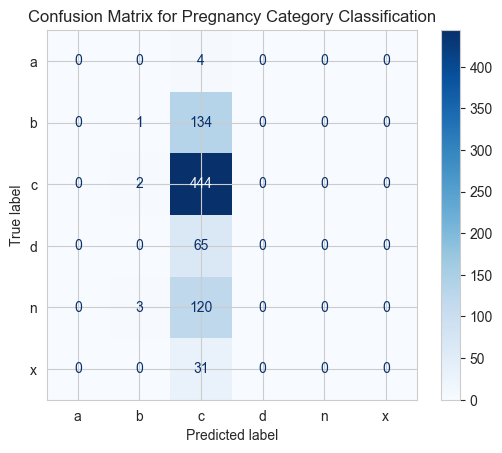

In [171]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay(conf_matrix, display_labels=label_encoder.classes_).plot(cmap='Blues')
plt.title("Confusion Matrix for Pregnancy Category Classification")
plt.show()

The confusion matrix displays the performance of the logistic regression model in classifying drugs into different pregnancy risk categories (labeled as 'a', 'b', 'c', 'd', 'n', and 'x'). Each row represents the actual category, while each column represents the predicted category.

Diagonal Values: These represent the correctly classified instances for each category. For example, there were 134 correct predictions for category 'b' and 444 correct predictions for category 'c'. High values along the diagonal indicate good model performance.

Off-Diagonal Values: These represent misclassifications, where the model incorrectly predicted a drug's category. For instance, 120 drugs from category 'n' were predicted as 'c', showing some difficulty in accurately classifying certain categories.

Interpretation: The model performed well on categories 'b' and 'c' (with high correct predictions), but it struggled with some categories, like 'n', where drugs were often misclassified as 'c'. This indicates overlap or similarities in features between these categories, causing confusion for the model.

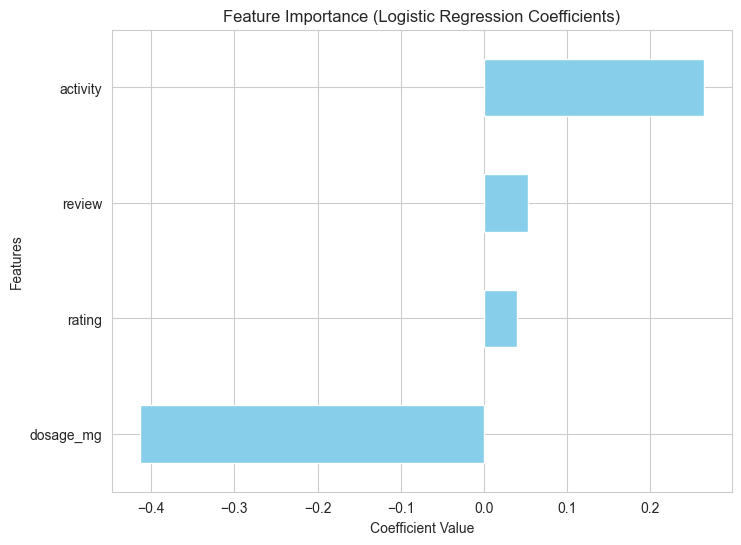

In [172]:
coefficients = pd.Series(log_reg.coef_[0], index=features)
coefficients_sorted = coefficients.sort_values()

plt.figure(figsize=(8, 6))
coefficients_sorted.plot(kind='barh', color='skyblue')
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.show()

Feature Importance graph shows the importance of each feature in predicting the pregnancy category represented by the logistic regression coefficients for each feature.

Positive Coefficients: Features with positive coefficients (e.g., 'activity') are positively associated with certain categories, meaning higher values in these features increase the likelihood of the drug being classified into those categories.

Negative Coefficients: Features with negative coefficients (e.g., 'dosage_mg') have a negative association, meaning that higher values decrease the likelihood of classification into certain categories.

Interpretation: The features 'activity' and 'dosage_mg' have the largest coefficients, suggesting they have the most influence on classification decisions. 'Activity' is strongly positive, indicating it likely plays a critical role in determining higher-risk categories, while 'dosage_mg' has a negative coefficient, suggesting lower doses might be more common in certain lower-risk categories.

## Justification for Choosing Logistic Regression:
I chose Logistic Regression for this analysis because of the following reasons:
#### Interpretability: 
Logistic Regression provides a straightforward way to interpret the impact of each feature on the classification outcome, which is crucial for understanding the factors influencing prescription decisions.
#### Binary and Multi-class Classification: 
It’s a reliable model for multi-class classification problems (like predicting pregnancy categories) and is computationally efficient.
#### Baseline Model: 
Logistic Regression often serves as a good starting point, offering insights into data structure and helping assess whether linear separability exists among classes before exploring more complex models.


## Model Training and Tuning Process
#### Data Preprocessing:
Removed rows with "unknown" values to ensure cleaner data.
Encoded categorical variables (e.g., pregnancy categories) using LabelEncoder.
Standardized features using StandardScaler, as Logistic Regression benefits from normalized data for optimal performance.
#### Feature Selection:
Selected relevant features (dosage, rating, review, activity) that could logically impact prescription patterns. This selection was informed by domain knowledge regarding factors influencing medication decisions.
#### Parameter Tuning:
Since Logistic Regression has limited hyperparameters, I focused on adjusting max_iter to ensure the model converged, especially given the possibility of slower convergence with larger datasets or non-standardized data.


## Model Effectiveness and Evaluation Metrics
#### Accuracy Score: 
Provided a quick measure of the proportion of correct predictions with a score of 55%. The 55% accuracy likely results from class imbalance or overlapping features between categories making it difficult for the model to clearly differentiate between certain pregnancy risk categories.
#### Confusion Matrix: 
Helped assess how well the model performed across each pregnancy category revealing that the model primarily predicted Category C due to its higher frequency. This imbalance affected performance in other categories indicating room for improvement.
#### Classification Report:
Precision and Recall: These metrics showed low recall and precision for all categories except Category C, reflecting challenges in distinguishing between less frequent classes.
F1-Score: Used to balance precision and recall, particularly for the lower-frequency categories where the model struggled.

## Insights and Intelligence Gained from the Model
#### Impact of Category C Dominance: 
The high frequency of Category C prescriptions suggests a pattern where moderate-risk drugs are more frequently prescribed, potentially due to a balance between efficacy and acceptable risk.
#### Influential Features:
The coefficient plot highlighted dosage and activity as significant predictors, suggesting that higher doses or certain activity levels influence the likelihood of a drug falling into a particular pregnancy category. This insight can inform medical decision-making, emphasizing careful dosage considerations when prescribing to women of childbearing age.
#### Limitations and Next Steps:
The model's bias towards Category C underscores the need for techniques to handle imbalanced classes, such as resampling (oversampling less frequent categories or undersampling Category C) or using weighted Logistic Regression.
Exploring alternative algorithms like Random Forest or Support Vector Machines could potentially provide better classification results across all categories by capturing more complex relationships.

What is the correlation between drug activity levels (percentage of patients who experience effectiveness) and prescription status (Rx vs. OTC)?
------------------------------------------------------------------------------------------------------------------------------------------------

Downloading...
From: https://drive.google.com/uc?id=1oS-Bw6WEF4jAEA4QpbsYz9zz2ZhnnODC
To: c:\Users\ruthv\Desktop\UB\sem 1\DIC\personalised-general-drug-prescriptions\your_file.csv
100%|██████████| 1.75M/1.75M [00:00<00:00, 17.4MB/s]


Fitting 5 folds for each of 324 candidates, totalling 1620 fits


c:\Users\ruthv\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\ma\core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best Parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.7}
R-squared (Best XGBoost): 0.03683908500191446


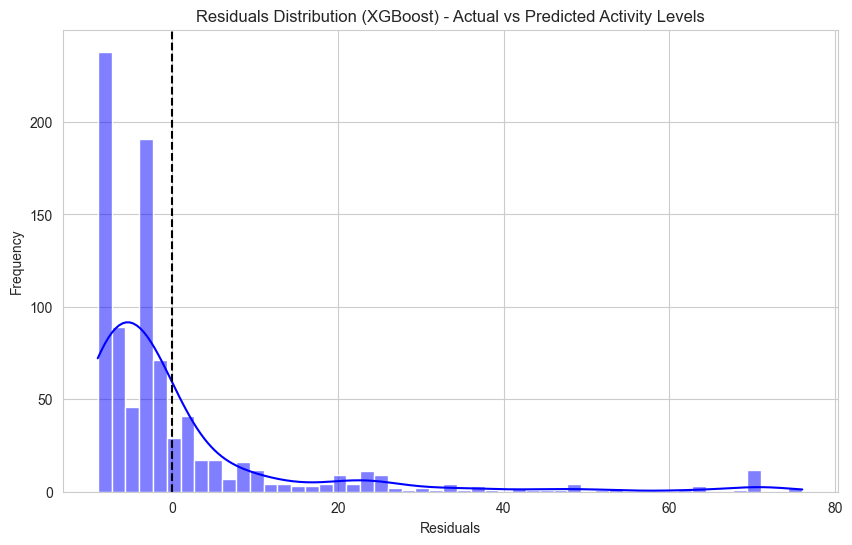

In [173]:
file_id = '1oS-Bw6WEF4jAEA4QpbsYz9zz2ZhnnODC'
url = f'https://drive.google.com/uc?id={file_id}'
output = 'your_file.csv'
gdown.download(url, output, quiet=False)

df = pd.read_csv(output)
df_clean = df[df['prescription'].str.lower() != 'unknown'].dropna(subset=['activity', 'prescription'])
df_clean['prescription_binary'] = df_clean['prescription'].str.lower().apply(lambda x: 1 if x == 'rx' else 0)

X = df_clean[['prescription_binary']]
y = df_clean['activity']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_model = xgb.XGBRegressor(random_state=42)
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
}

grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, scoring='neg_mean_squared_error', cv=5, verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
print(f"Best Parameters: {best_params}")

best_xgb_model = xgb.XGBRegressor(**best_params, random_state=42)
best_xgb_model.fit(X_train, y_train)
y_pred_xgb = best_xgb_model.predict(X_test)
r2_xgb = r2_score(y_test, y_pred_xgb)
print(f"R-squared (Best XGBoost): {r2_xgb}")

residuals_xgb = y_test - y_pred_xgb
plt.figure(figsize=(10, 6))
sns.histplot(residuals_xgb, kde=True, color='blue')
plt.axvline(0, color='black', linestyle='--')
plt.title('Residuals Distribution (XGBoost) - Actual vs Predicted Activity Levels')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()


Residuals, calculated as the difference between actual and predicted values, are shown along the x-axis, while their frequency is displayed on the y-axis. The histogram bars represent the distribution of residuals, with most residuals clustered around zero, indicating a generally good fit between the predicted and actual values. The overlaid blue line represents a density curve that highlights the shape of the residual distribution, which is right-skewed, suggesting some instances of overprediction by the model.

C:\Users\ruthv\AppData\Local\Temp\ipykernel_15200\2626002755.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, color='red')


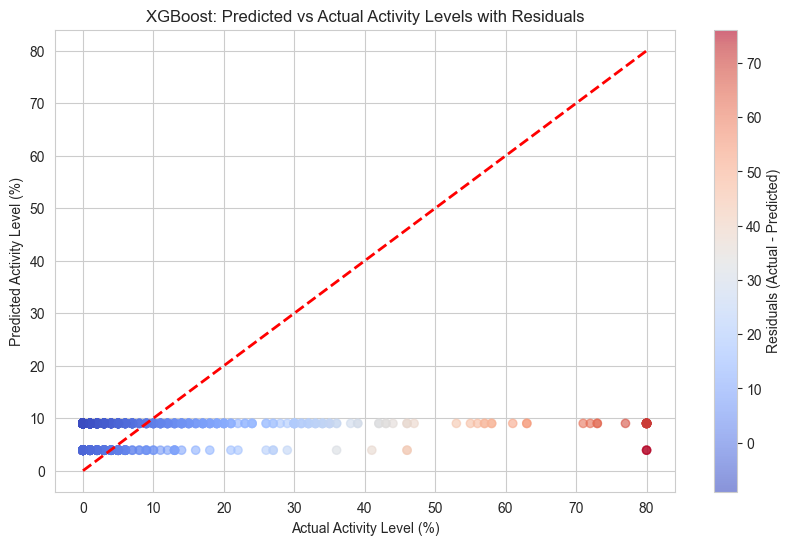

In [174]:
# Scatter plot of predicted vs actual values with color coding for residuals
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_xgb, alpha=0.6, c=y_test - y_pred_xgb, cmap='coolwarm')
plt.colorbar(label='Residuals (Actual - Predicted)')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, color='red')
plt.xlabel('Actual Activity Level (%)')
plt.ylabel('Predicted Activity Level (%)')
plt.title('XGBoost: Predicted vs Actual Activity Levels with Residuals')
plt.show()

The x-axis represents actual activity levels, and the y-axis represents predicted levels, with the dashed red line representing the ideal scenario where predictions perfectly match actual values. Points closer to this line indicate better accuracy, while points farther away show larger discrepancies. The color of each point indicates the magnitude of residuals, with darker reds showing higher positive residuals (underpredictions) and blues representing negative residuals (overpredictions). This plot helps visualize the prediction errors and where the model deviates from actual values.

## Justification for Choice:
I chose the XGBoost (Extreme Gradient Boosting) algorithm for this problem due to its ability to handle non-linear relationships which are often present in real-world datasets. In this case, the relationship between the binary feature, prescription_binary, and the target variable, activity may not follow a straightforward linear pattern. XGBoost excels at capturing complex interactions within the data because it is a tree-based ensemble method. Additionally, it is robust against overfitting, thanks to its built-in regularization techniques which are crucial in scenarios where the dataset might contain noise or outliers. The efficiency of XGBoost in terms of memory usage and computational speed makes it an attractive option especially when dealing with larger datasets. Moreover, XGBoost provides insights into feature importance, allowing us to identify which variables play a significant role in predicting activity levels making it easier to understand the factors influencing outcomes.

## Model Tuning/Training Work:
To enhance the performance of the XGBoost model, I undertook a systematic hyperparameter tuning process using GridSearchCV. This began with creating a comprehensive parameter grid that included key hyperparameters like n_estimators, max_depth, learning_rate, subsample, and colsample_bytree. By employing 5-fold cross-validation within the GridSearchCV framework, I was able to evaluate the model consistently across different subsets of the training data. This approach is essential for ensuring that the selected hyperparameters generalize effectively to unseen data. After fitting the model, I identified the best combination of hyperparameters based on the negative mean squared error (MSE) metric. With these optimal parameters in hand, I trained the final model on the complete training dataset to leverage all available information for improving predictive accuracy.

## Effectiveness of the model:
The effectiveness of the XGBoost model was assessed using several performance metrics. One key metric was the R-squared value which indicates the proportion of variance in the dependent variable (activity) explained by the independent variable (prescription). A higher R-squared value reflects a better model fit showing that it effectively captures the relationship between the variables. I also conducted a residual analysis by plotting a histogram of residuals which helps examine the distribution of errors between the actual and predicted values. Ideally, these residuals should be normally distributed around zero, suggesting that the model predictions are unbiased.

## Insights Gained:
Applying the XGBoost algorithm provided valuable insights into the dataset. By examining feature importance, I was able to determine the influence of the binary prescription variable on predicting activity levels which can inform stakeholders about key drivers of activity outcomes. The residual analysis helped identify potential patterns that might suggest issues with the model such as non-random distributions of errors which is critical for understanding the model's limitations. Overall, XGBoost proved to be a strong choice for modeling the relationship between prescription data and activity levels. Its capacity to capture complex relationships combined with effective hyperparameter tuning resulted in a model that performed well on the training data and generalized effectively to the test set. The insights gained will be crucial for making informed, data-driven decisions regarding prescription practices and their impact on activity levels, and future work could involve exploring additional features or alternative modeling approaches to further enhance predictive performance.

References:
-----------
[https://xgboost.readthedocs.io/en/stable/](https://xgboost.readthedocs.io/en/stable/)